In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import pandas as pd

# Einstellungen
BASE_DIR = '/datasets/multi-view-pig-posture-recognition'
NUM_IMAGES = 500         # Wir nehmen nur 500 Bilder zum Testen
BATCH_SIZE = 32          # 32 Bilder pro Schritt
NUM_EPOCHS = 5           # 3 Durchgänge reichen für den ersten Eindruck
LEARNING_RATE = 0.001

# Prüfen auf GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training läuft auf: {device}")

<jemalloc>: Unsupported system page size


Training läuft auf: cpu


/opt/conda/envs/torch/lib/python3.10/site-packages/torch/cuda/__init__.py:83: UserWarning: CUDA initialization: CUDA driver initialization failed, you might not have a CUDA gpu. (Triggered internally at  /data/miniconda3/envs/opence-1.7/conda-bld/pytorch-base_1664908798504/work/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
# 1. CSVs einlesen
df1 = pd.read_csv(os.path.join(BASE_DIR, 'train1.csv'))
df2 = pd.read_csv(os.path.join(BASE_DIR, 'train2.csv'))

# 2. Zusammenfügen
df_full = pd.concat([df1, df2], ignore_index=True)

# 3. Pfade korrekt bauen (image_id + .jpg, falls nötig)
def get_full_path(row):
    # Ordner bestimmen (train1 oder train2) based on filename usually, 
    # aber wir wissen: df1 -> train1_images, df2 -> train2_images.
    # Der Einfachheit halber prüfen wir, wo die Datei liegt:
    fname = str(row['image_id'])
    if not fname.endswith('.jpg'):
        fname += '.jpg'
        
    path1 = os.path.join(BASE_DIR, 'train1_images', fname)
    if os.path.exists(path1):
        return path1
    return os.path.join(BASE_DIR, 'train2_images', fname)

df_full['path'] = df_full.apply(get_full_path, axis=1)

# 4. Nur 500 zufällige Bilder auswählen
df_subset = df_full.sample(n=NUM_IMAGES, random_state=42).copy().reset_index(drop=True)

# 5. Labels in Zahlen umwandeln (0, 1, 2...)
# Wir nutzen 'class_id' als Label
le = LabelEncoder()
df_subset['label_encoded'] = le.fit_transform(df_subset['class_id'].astype(str))
num_classes = len(le.classes_)

print(f" Daten vorbereitet: {len(df_subset)} Bilder ausgewählt.")
print(f" Anzahl Klassen: {num_classes} -> {le.classes_}")

 Daten vorbereitet: 500 Bilder ausgewählt.
 Anzahl Klassen: 5 -> ['0' '1' '2' '3' '4']


In [3]:
class PigDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        label = row['label_encoded']
        
        try:
            # Bild laden und in RGB wandeln (wichtig!)
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            # Falls ein Bild kaputt ist, erzeugen wir ein schwarzes Ersatzbild
            # (Damit das Training nicht abstürzt)
            print(f"Fehler bei Bild {img_path}: {e}")
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)
            
        # Rückgabe: Das Bild und das passende Label
        return image, torch.tensor(label, dtype=torch.long)

In [4]:
# Bild-Transformationen (Standard für ResNet)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Größe anpassen
    transforms.ToTensor(),          # In Zahlen umwandeln
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]) # Farben normalisieren
])

# Dataset und DataLoader erstellen
dataset = PigDataset(df_subset, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [5]:
# 1. Modell laden (pretrained=True heißt: Es hat schon "Seherfahrung")
model = models.resnet18(pretrained=True)

# 2. Letzte Schicht austauschen
# (Original hat 1000 Klassen, wir brauchen nur 'num_classes')
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

# 3. Modell auf GPU/CPU schieben
model = model.to(device)

# 4. Werkzeuge zum Lernen
criterion = nn.CrossEntropyLoss()      # Misst den Fehler
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # Verbessert das Modell

In [8]:
# Listen zum Speichern der Ergebnisse
train_losses = []
train_accs = []

print(f"Starte Training fuer {NUM_EPOCHS} Epochen...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Ladebalken
    loop = tqdm(dataloader, desc=f"Epoche {epoch+1}/{NUM_EPOCHS}")
    
    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)
        
        # Trainingsschritt
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Statistik
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        loop.set_postfix(loss=loss.item())
    
    # Durchschnittswerte berechnen
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    # Werte in der Liste speichern
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    
    print(f"Epoche {epoch+1}: Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("Training abgeschlossen.")

Starte Training fuer 5 Epochen...


Epoche 1/5: 100%|███████████████████| 16/16 [00:23<00:00,  1.47s/it, loss=0.952]


Epoche 1: Loss: 0.7339 | Accuracy: 72.60%


Epoche 2/5: 100%|███████████████████| 16/16 [00:21<00:00,  1.33s/it, loss=0.908]


Epoche 2: Loss: 0.5554 | Accuracy: 80.20%


...

Epoche 3: Loss: 0.5709 | Accuracy: 78.40%


Epoche 4/5: 100%|███████████████████| 16/16 [00:20<00:00,  1.28s/it, loss=0.481]


Epoche 4: Loss: 0.4143 | Accuracy: 86.20%


Epoche 5/5: 100%|███████████████████| 16/16 [00:18<00:00,  1.19s/it, loss=0.455]

Epoche 5: Loss: 0.3683 | Accuracy: 85.60%
Training abgeschlossen.


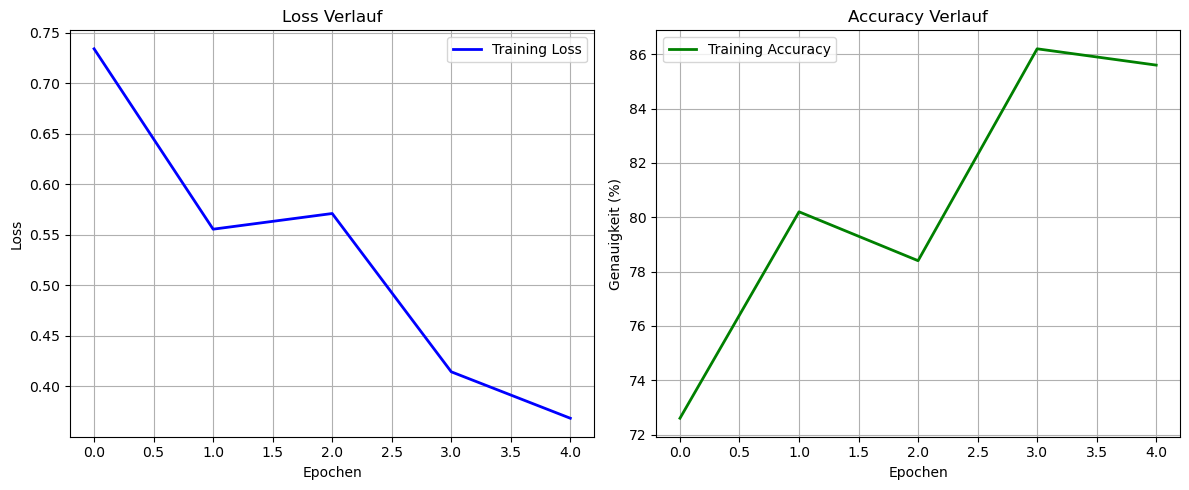

In [9]:
import matplotlib.pyplot as plt

# Plot erstellen (2 Diagramme nebeneinander)
plt.figure(figsize=(12, 5))

# 1. Loss Kurve (Fehler)
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
plt.title('Loss Verlauf')
plt.xlabel('Epochen')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# 2. Accuracy Kurve (Genauigkeit)
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training Accuracy', color='green', linewidth=2)
plt.title('Accuracy Verlauf')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

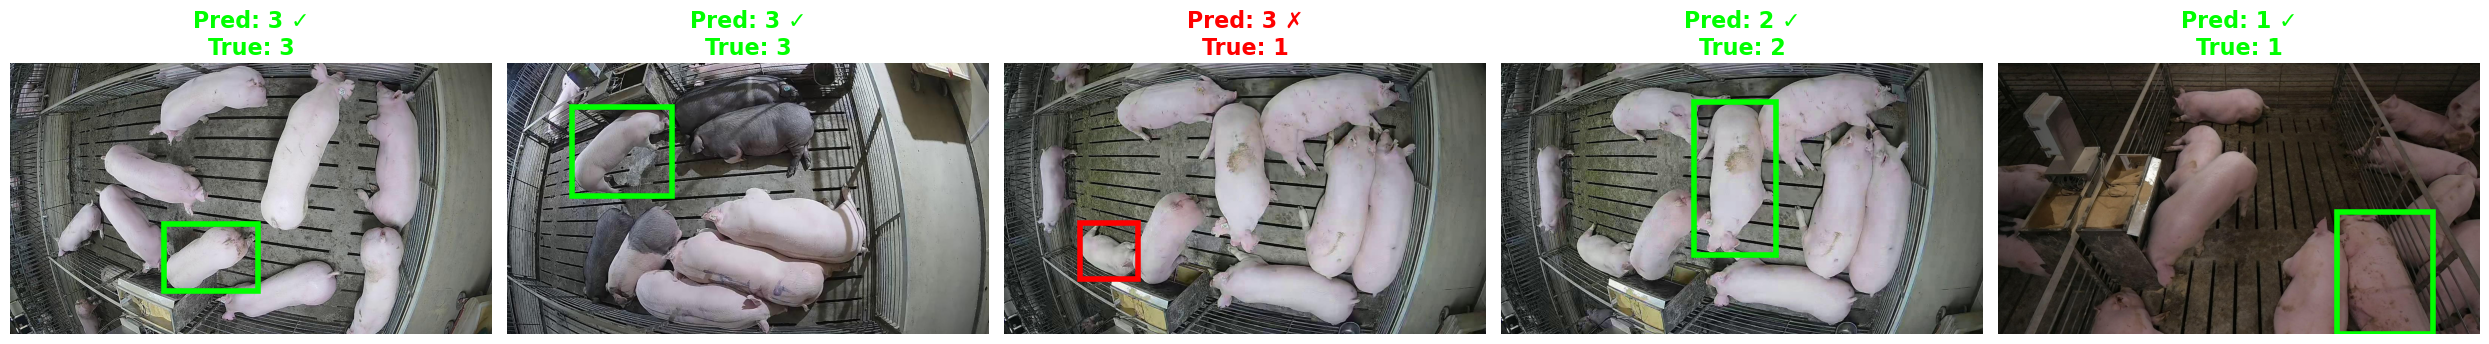

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
import ast
import random

# 1. Modell in den "Evaluierungs-Modus" schalten (Wichtig!)
model.eval()

# 2. 5 zufällige Testbilder auswählen
# Wir nehmen df_subset, das wir für das Training erstellt haben
# Falls df_subset nicht mehr existiert, nutzen wir df_train_full
data_source = df_subset if 'df_subset' in locals() else df_train_full
test_samples = data_source.sample(n=5)

# Plot vorbereiten
plt.figure(figsize=(25, 8))

# Wir brauchen keine Gradienten mehr (spart Speicher)
with torch.no_grad():
    for i, (index, row) in enumerate(test_samples.iterrows()):
        ax = plt.subplot(1, 5, i + 1)
        
        # --- BILD LADEN ---
        img_path = row['path']
        try:
            # Bild laden und in RGB wandeln
            image_pil = Image.open(img_path).convert("RGB")
        except Exception as e:
            ax.text(0.5, 0.5, "Bild nicht gefunden", ha='center')
            continue 
            
        # --- VORHERSAGE ---
        # Bild für das Modell vorbereiten (wie beim Training: Resize, ToTensor...)
        input_tensor = transform(image_pil)
        # Eine "Mini-Batch" aus 1 Bild machen: [3, 224, 224] -> [1, 3, 224, 224]
        input_batch = input_tensor.unsqueeze(0).to(device)
        
        # Modell fragen
        outputs = model(input_batch)
        _, preds = torch.max(outputs, 1)
        
        # Ergebnis auswerten (Zahlen)
        predicted_idx = preds.item()
        
        # Label holen (Text oder Zahl)
        # Falls wir vorher 'label_encoded' erstellt haben:
        if 'label_encoded' in row:
            true_idx = row['label_encoded']
        else:
            # Fallback falls Label nicht kodiert ist
            true_idx = -1 
        
        # Text-Labels für die Anzeige holen (falls LabelEncoder 'le' da ist)
        if 'le' in locals():
            pred_text = le.inverse_transform([predicted_idx])[0]
            if true_idx != -1:
                true_text = le.inverse_transform([true_idx])[0]
            else:
                true_text = str(row.get('class_id', '?'))
        else:
            pred_text = str(predicted_idx)
            true_text = str(true_idx)
        
        # --- VISUALISIERUNG ---
        ax.imshow(image_pil)
        
        # Box zeichnen
        bbox_data = row.get('bbox', None)
        if bbox_data:
            # String "[...]" in echte Liste wandeln, falls nötig
            if isinstance(bbox_data, str):
                bbox = ast.literal_eval(bbox_data)
            else:
                bbox = bbox_data
            
            x, y, w, h = bbox[0], bbox[1], bbox[2], bbox[3]
            
            # Farbe bestimmen: Grün = Richtig, Rot = Falsch
            # (Nur wenn wir ein echtes Label zum Vergleichen haben)
            if true_idx != -1 and predicted_idx == true_idx:
                color = 'lime'      # Knallgrün (Richtig)
                status_symbol = "✓"
            else:
                color = 'red'       # Rot (Falsch)
                status_symbol = "✗"
            
            # Rechteck
            rect = patches.Rectangle(
                (x, y), w, h, 
                linewidth=4,        # Dicke Linie
                edgecolor=color, 
                facecolor='none'
            )
            ax.add_patch(rect)
            
            # Titel über dem Bild
            title = f"Pred: {pred_text} {status_symbol}\nTrue: {true_text}"
            ax.set_title(title, color=color, fontsize=16, fontweight='bold')
            
        ax.axis('off')

plt.tight_layout()
plt.show()